# NUS ST5209X — Analysis of Time Series Data
## End-to-end case study: modelling and forecasting atmospheric CO₂

This notebook is designed as a **teaching companion** for the major ideas in graduate-level time-series analysis. Rather than presenting isolated formulas, we use one real dataset from start to finish and repeatedly ask four questions:

1. **What temporal structure is present?**
2. **What statistical assumptions are we making?**
3. **How do we diagnose whether a model has captured the structure?**
4. **Does the model actually forecast unseen future observations well?**

The case study uses atmospheric CO₂ measurements from Mauna Loa, distributed with `statsmodels`. The raw series is weekly; we aggregate it to monthly means so that annual seasonality corresponds naturally to period $m=12$.

### Concepts covered

- temporal indexing and data quality;
- trend, seasonality, cycles and remainder;
- transformations and differencing;
- autocovariance, ACF and PACF;
- weak stationarity;
- ADF and KPSS stationarity tests;
- white noise and residual diagnostics;
- naïve and seasonal-naïve forecasting;
- exponential smoothing / Holt-Winters;
- AR, MA, ARMA and ARIMA intuition;
- SARIMA estimation and information criteria;
- residual checking and Ljung-Box testing;
- prediction intervals;
- state-space models and Kalman filtering;
- spectral / frequency-domain analysis;
- time-aware model validation;
- supervised ML forecasting using lag features;
- comparison of classical statistical and machine-learning forecasts.

---

## The central forecasting problem

At time $T$, we have observed

$$
y_1, y_2, \ldots, y_T.
$$

We want to estimate future values

$$
y_{T+1}, y_{T+2}, \ldots, y_{T+h}
$$

without leaking information from the future into model training.

That last phrase—**without leakage**—is what makes time-series evaluation fundamentally different from ordinary random train/test splitting.

## 1. Environment and imports

The notebook deliberately uses mainstream libraries so the workflow is reproducible:

- `pandas` / `numpy` for data manipulation;
- `statsmodels` for classical time-series statistics;
- `scikit-learn` for ML forecasting;
- `scipy` for spectral analysis;
- `bokeh` for interactive visualisation.

If a package is missing, install it with `pip install pandas numpy scipy statsmodels scikit-learn bokeh`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import warnings

import numpy as np
import pandas as pd

from scipy.signal import periodogram

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.structural import UnobservedComponents

from bokeh.io import output_notebook, show
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, HoverTool, Span
from bokeh.palettes import Category10
from bokeh.plotting import figure

warnings.filterwarnings("ignore")
output_notebook()

RANDOM_STATE = 42
SEASONAL_PERIOD = 12

Loading BokehJS ...

## 2. Reusable helpers

A repeated weakness in analytical notebooks is copy-pasted plotting and evaluation code. Here we encapsulate common operations so that the notebook is easier to extend.

The `ForecastMetrics` class computes several complementary measures:

- **MAE**: average absolute error;
- **RMSE**: penalises large misses more strongly;
- **sMAPE**: scale-free percentage-like error;
- **MASE**: compares absolute forecast error against a naïve in-sample benchmark.

For MASE, values below 1 are especially intuitive: the forecast beats the chosen naïve benchmark on average.

In [48]:
@dataclass
class ForecastMetrics:
    seasonal_period: int = 12

    @staticmethod
    def smape(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        denom = np.abs(y_true) + np.abs(y_pred)
        ratio = np.divide(
            2.0 * np.abs(y_true - y_pred),
            denom,
            out=np.zeros_like(denom, dtype=float),
            where=denom != 0,
        )
        return 100.0 * ratio.mean()

    def mase(
        self,
        y_train: Sequence[float],
        y_true: Sequence[float],
        y_pred: Sequence[float],
    ) -> float:
        y_train = np.asarray(y_train, dtype=float)
        if len(y_train) <= self.seasonal_period:
            raise ValueError("Training series is too short for seasonal MASE.")

        scale = np.mean(
            np.abs(
                y_train[self.seasonal_period:]
                - y_train[:-self.seasonal_period]
            )
        )
        return mean_absolute_error(y_true, y_pred) / scale

    def evaluate(
        self,
        model_name: str,
        y_train: Sequence[float],
        y_true: Sequence[float],
        y_pred: Sequence[float],
    ) -> Dict[str, float]:
        return {
            "model": model_name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "sMAPE_pct": self.smape(y_true, y_pred),
            "MASE": self.mase(y_train, y_true, y_pred),
        }


def line_plot(
    series_map: Dict[str, pd.Series],
    title: str,
    y_label: str,
    width: int = 950,
    height: int = 390,
):
    p = figure(
        width=width,
        height=height,
        x_axis_type="datetime",
        title=title,
        toolbar_location="above",
    )
    palette = Category10[10]

    for i, (name, s) in enumerate(series_map.items()):
        s = pd.Series(s).dropna()
        p.line(
            s.index,
            s.values,
            line_width=2,
            color=palette[i % len(palette)],
            legend_label=name,
        )

    p.xaxis.axis_label = "Time"
    p.yaxis.axis_label = y_label
    p.legend.location = "top_left"
    p.legend.click_policy = "hide"
    p.add_tools(HoverTool(tooltips=[("time", "$x{%F}"), ("value", "$y{0.000}")], formatters={"$x": "datetime"}))
    return p


def table_metrics(rows: List[Dict[str, float]]) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    numeric = [c for c in df.columns if c != "model"]
    df[numeric] = df[numeric].round(4)
    return df.sort_values(["MASE", "RMSE"]).reset_index(drop=True)

## 3. Load the real-world dataset

`statsmodels.datasets.co2` contains atmospheric CO₂ measurements observed at Mauna Loa. We convert the weekly data to monthly means.

Why monthly?

- the underlying phenomenon has a strong yearly seasonal cycle;
- monthly data make the seasonal period explicit: $m=12$;
- SARIMA and decomposition models become quicker to fit and easier to interpret pedagogically.

In [3]:
raw = sm.datasets.co2.load_pandas().data.copy()
raw.index = pd.to_datetime(raw.index)
raw = raw.sort_index()

monthly = raw["co2"].resample("MS").mean()

# Interpolate occasional missing monthly means using time-aware interpolation.
monthly = monthly.interpolate(method="time").rename("co2")

print(f"Weekly observations in source: {len(raw):,}")
print(f"Monthly observations after aggregation: {len(monthly):,}")
print(f"Date range: {monthly.index.min().date()} to {monthly.index.max().date()}")
print(f"Missing monthly values after interpolation: {monthly.isna().sum()}")

display(monthly.head())
display(monthly.tail())

Weekly observations in source: 2,284
Monthly observations after aggregation: 526
Date range: 1958-03-01 to 2001-12-01
Missing monthly values after interpolation: 0


1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.514344
1958-07-01    315.625000
Freq: MS, Name: co2, dtype: float64

2001-08-01    369.425
2001-09-01    367.880
2001-10-01    368.050
2001-11-01    369.375
2001-12-01    371.020
Freq: MS, Name: co2, dtype: float64

### What should we notice before modelling?

A time-series model assumes the time index itself is meaningful. Therefore a minimal audit should check:

1. observations are ordered chronologically;
2. the index has a regular frequency;
3. there are no unresolved missing values;
4. the physical scale is sensible;
5. large discontinuities are investigated before being labelled as “noise”.

This is analogous to schema validation in data engineering: **a statistical model cannot repair a broken temporal contract**.

In [54]:
audit = pd.DataFrame({
    "n_observations": [len(monthly)],
    "start": [monthly.index.min()],
    "end": [monthly.index.max()],
    "missing": [monthly.isna().sum()],
    "minimum": [monthly.min()],
    "maximum": [monthly.max()],
    "mean": [monthly.mean()],
    "std_dev": [monthly.std()],
})

display(audit.round(3))
show(line_plot({"Monthly CO₂": monthly}, "Monthly atmospheric CO₂", "CO₂ (ppm)"))

,n_observations,start,end,missing,minimum,maximum,mean,std_dev
0,526,1958-03-01,2001-12-01,0,313.4,373.8,339.619,17.116


## 4. Trend, seasonality and local variation

A useful conceptual decomposition is

$$
y_t = T_t + S_t + R_t,
$$

where

- $T_t$ is the slowly varying trend;
- $S_t$ is a systematic seasonal effect;
- $R_t$ is the remainder.

The raw CO₂ plot shows two structures simultaneously:

- a strong upward long-run trend;
- oscillations repeating approximately every 12 months.

A rolling mean helps expose the slower component while a rolling standard deviation helps us see whether variability changes materially over time.

In [47]:
rolling_12_mean = monthly.rolling(12, center=True).mean().rename("12-month rolling mean")
rolling_12_std = monthly.rolling(12, center=True).std().rename("12-month rolling std")

show(line_plot(
    {"Observed": monthly, "12-month rolling mean": rolling_12_mean},
    "Observed series and local trend estimate",
    "CO₂ (ppm)",
))

show(line_plot(
    {"12-month rolling std": rolling_12_std},
    "Rolling variability",
    "Rolling standard deviation",
))

## 5. STL decomposition

STL stands for **Seasonal-Trend decomposition using LOESS**. It estimates a smooth trend and recurring seasonal component without requiring us to specify a full stochastic model first.

We use period 12 because the data are monthly.

A useful diagnostic question is:

> After removing trend and seasonality, does the remainder look structureless?

If not, a forecasting model may still need to represent additional serial dependence.

In [46]:
stl = STL(monthly, period=SEASONAL_PERIOD, robust=True).fit()

stl_trend = pd.Series(stl.trend, index=monthly.index, name="Trend")
stl_seasonal = pd.Series(stl.seasonal, index=monthly.index, name="Seasonal")
stl_resid = pd.Series(stl.resid, index=monthly.index, name="Remainder")

show(column(
    line_plot({"Observed": monthly}, "STL: observed", "CO₂ (ppm)", height=260),
    line_plot({"Trend": stl_trend}, "STL: trend", "CO₂ (ppm)", height=260),
    line_plot({"Seasonal": stl_seasonal}, "STL: seasonal component", "ppm", height=260),
    line_plot({"Remainder": stl_resid}, "STL: remainder", "ppm", height=260),
))

## 6. Transformations and differencing

A stationary process has stable first- and second-order structure over time. In weak form, we want approximately

$$
E[Y_t] = \mu,
$$

$$
\operatorname{Var}(Y_t) = \sigma^2,
$$

and

$$
\operatorname{Cov}(Y_t, Y_{t-k}) = \gamma(k),
$$

where the covariance depends on the **lag** $k$ rather than the absolute date $t$.

The raw CO₂ series is visibly non-stationary because its mean rises over time.

Two common operations are:

### First difference

$$
\Delta y_t = y_t - y_{t-1}.
$$

This removes a slowly varying level or stochastic trend.

### Seasonal difference

$$
\Delta_{12} y_t = y_t - y_{t-12}.
$$

This compares each month to the same month one year earlier and suppresses annual seasonality.

For SARIMA, we often combine both:

$$
(1-B)(1-B^{12})y_t.
$$

In [53]:
first_diff = monthly.diff().rename("First difference")
seasonal_diff = monthly.diff(SEASONAL_PERIOD).rename("Seasonal difference")
combined_diff = monthly.diff().diff(SEASONAL_PERIOD).rename("First + seasonal difference")

show(column(
    line_plot({"Raw": monthly}, "Raw monthly CO₂", "ppm", height=260),
    line_plot({"First difference": first_diff}, "First-differenced series", "Δ CO₂", height=260),
    line_plot({"Seasonal difference": seasonal_diff}, "12-month seasonally differenced series", "Δ₁₂ CO₂", height=260),
    line_plot({"Combined": combined_diff}, "First + seasonal differencing", "Differenced CO₂", height=260),
))

## 7. Formal stationarity checks: ADF and KPSS

No single test should be treated as an oracle. A better habit is to combine plots, domain reasoning and tests with **opposite null hypotheses**.

### Augmented Dickey-Fuller (ADF)

- $H_0$: unit root / non-stationarity;
- a small p-value provides evidence against the unit-root null.

### KPSS

- $H_0$: stationarity around a deterministic component;
- a small p-value provides evidence against stationarity.

Using both tests helps us avoid a simplistic “one p-value decides everything” workflow.

In [52]:
def stationarity_tests(series: pd.Series, name: str) -> Dict[str, float]:
    s = series.dropna().astype(float)

    adf_result = adfuller(s, autolag="AIC")
    kpss_result = kpss(s, regression="c", nlags="auto")

    return {
        "series": name,
        "ADF_stat": adf_result[0],
        "ADF_p": adf_result[1],
        "KPSS_stat": kpss_result[0],
        "KPSS_p": kpss_result[1],
    }

stationarity_df = pd.DataFrame([
    stationarity_tests(monthly, "raw"),
    stationarity_tests(first_diff, "first_difference"),
    stationarity_tests(seasonal_diff, "seasonal_difference"),
    stationarity_tests(combined_diff, "first_plus_seasonal_difference"),
])

display(stationarity_df.round(4))

,series,ADF_stat,ADF_p,KPSS_stat,KPSS_p
0,raw,2.2340,0.9989,3.3694,0.01
1,first_difference,-4.7529,0.0001,0.3000,0.10
2,seasonal_difference,-4.2909,0.0005,1.1829,0.01
3,first_plus_seasonal_difference,-8.4006,0.0000,0.0204,0.10


### Interpretation rule of thumb

A useful pattern is:

| ADF | KPSS | Interpretation |
|---|---|---|
| fail to reject unit root | reject stationarity | strongly suggests non-stationarity |
| reject unit root | fail to reject stationarity | strongly supports stationarity |
| both reject | conflicting evidence; inspect structural breaks / deterministic trends |
| neither rejects | low power / ambiguous; use plots and domain knowledge |

For this dataset, differencing should materially improve stationarity because it suppresses the long-run level movement.

## 8. ACF and PACF: measuring temporal dependence

The autocorrelation function is

$$
\rho(k) = \operatorname{Corr}(Y_t, Y_{t-k}).
$$

The partial autocorrelation at lag $k$ attempts to measure the direct relationship between $Y_t$ and $Y_{t-k}$ after accounting for intermediate lags.

Classical heuristics:

- AR($p$): PACF often cuts off after approximately $p$, while ACF tails off;
- MA($q$): ACF often cuts off after approximately $q$, while PACF tails off;
- ARMA: both usually tail off.

These are **diagnostic heuristics**, not immutable laws.

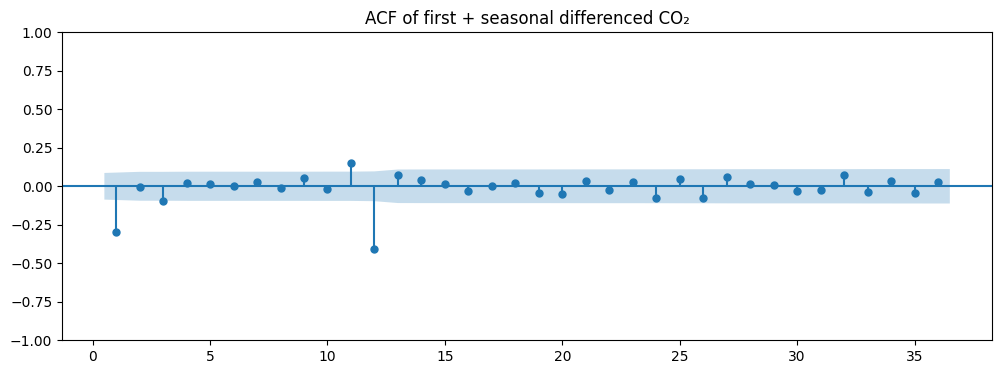

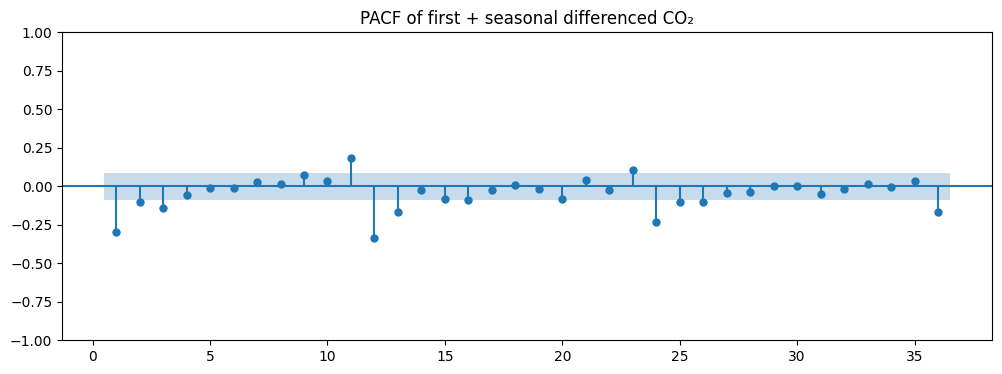

In [28]:
import matplotlib.pyplot as plt

acf_source = combined_diff.dropna()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(acf_source, lags=36, ax=ax, zero=False)
ax.set_title("ACF of first + seasonal differenced CO₂")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(acf_source, lags=36, ax=ax, zero=False, method="ywm")
ax.set_title("PACF of first + seasonal differenced CO₂")
plt.show()

## 9. AR, MA, ARMA and ARIMA — mathematical bridge

### Autoregressive model

An AR($p$) process is

$$
y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t.
$$

Current behaviour depends directly on previous observations.

### Moving-average model

An MA($q$) process is

$$
y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1}+\cdots+\theta_q\varepsilon_{t-q}.
$$

Current behaviour depends on current and previous **innovations**.

### ARMA

$$
\phi(B)y_t = \theta(B)\varepsilon_t.
$$

### ARIMA

If differencing is required, the model becomes

$$
\phi(B)(1-B)^d y_t = \theta(B)\varepsilon_t.
$$

### Seasonal ARIMA

For period $m$,

$$
SARIMA(p,d,q)(P,D,Q)_m
$$

adds seasonal AR, differencing and MA terms.

For monthly CO₂, $m=12$.

## 10. Forecast design: hold out the future

For model fitting we use the most recent **240 months (20 years)** of the series, then reserve the final **36 months** as a genuine future test set. The full historical series remains useful for EDA and structural analysis, while the shorter modelling window keeps repeated SARIMA fitting fast and focuses forecasting on the more recent regime.

This is very different from random `train_test_split`:

```text
past -------------------------------------- future
TRAIN                                      TEST
███████████████████████████████████████ | ███████
```

The model may learn only from the left side of the boundary.

In [29]:
TEST_HORIZON = 36
MODELLING_WINDOW = 240
model_series = monthly.iloc[-MODELLING_WINDOW:].copy()
train = model_series.iloc[:-TEST_HORIZON].copy()
test = model_series.iloc[-TEST_HORIZON:].copy()

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} months)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} months)")

p = line_plot({"Train": train, "Test": test}, "Chronological train/test split", "CO₂ (ppm)")
boundary = Span(location=test.index.min().timestamp() * 1000, dimension="height", line_dash="dashed", line_width=2)
p.add_layout(boundary)
show(p)

Train: 1982-01-01 -> 1998-12-01 (204 months)
Test : 1999-01-01 -> 2001-12-01 (36 months)


## 11. Baseline 1: naïve forecast

The naïve forecast says

$$
\hat y_{T+h} = y_T.
$$

It is intentionally simple. If an expensive model cannot beat this baseline, the complexity is not justified.

In [30]:
naive_forecast = pd.Series(
    np.repeat(train.iloc[-1], len(test)),
    index=test.index,
    name="Naive",
)

show(line_plot(
    {"Observed test": test, "Naive": naive_forecast},
    "Naïve forecast",
    "CO₂ (ppm)",
))

## 12. Baseline 2: seasonal naïve forecast

For monthly data with period 12,

$$
\hat y_{T+h} = y_{T+h-12k}
$$

for the most recent corresponding month available.

This baseline is much harder to beat when seasonality is strong because it preserves the seasonal shape almost for free.

In [31]:
def seasonal_naive_forecast(train: pd.Series, horizon: int, season_length: int) -> pd.Series:
    history = list(train.astype(float).values)
    preds = []
    for _ in range(horizon):
        pred = history[-season_length]
        preds.append(pred)
        history.append(pred)
    return pd.Series(preds)

seasonal_naive = seasonal_naive_forecast(train, len(test), SEASONAL_PERIOD)
seasonal_naive.index = test.index
seasonal_naive.name = "Seasonal naïve"

show(line_plot(
    {"Observed test": test, "Seasonal naïve": seasonal_naive},
    "Seasonal-naïve forecast",
    "CO₂ (ppm)",
))

## 13. Exponential smoothing / Holt-Winters

Exponential smoothing gives more weight to recent observations.

For simple exponential smoothing,

$$
\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}.
$$

Holt-Winters extends this idea by maintaining separate latent components for:

- level;
- trend;
- seasonality.

For CO₂ we use additive trend and additive seasonality because the size of the seasonal oscillation is relatively stable compared with the rising level.

In [32]:
ets_model = ExponentialSmoothing(
    train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="estimated",
).fit(optimized=True)

ets_forecast = pd.Series(
    ets_model.forecast(len(test)),
    index=test.index,
    name="ETS / Holt-Winters",
)

show(line_plot(
    {"Observed test": test, "ETS": ets_forecast},
    "Holt-Winters / exponential-smoothing forecast",
    "CO₂ (ppm)",
))

## 14. SARIMA model

We now use a classical seasonal ARIMA model:

$$
SARIMA(1,1,1)(0,1,1)_{12}.
$$

Interpretation:

- $p=1$: one non-seasonal AR term;
- $d=1$: one ordinary difference;
- $q=1$: one non-seasonal MA term;
- $P=0$: no seasonal AR term in this illustrative specification;
- $D=1$: one seasonal difference;
- $Q=1$: one seasonal MA term;
- $m=12$: yearly seasonality for monthly observations.

This is not claimed to be universally optimal. It is a sensible medium-complexity model for demonstrating the complete workflow.

In [14]:
sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, SEASONAL_PERIOD),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=80)

print(sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  204
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -41.324
Date:                            Wed, 09 Sep 2026   AIC                             90.648
Time:                                    14:31:51   BIC                            103.352
Sample:                                01-01-1982   HQIC                            95.800
                                     - 12-01-1998                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0923      0.216      0.427      0.669      -0.331       0.516
ma.L1         -0.4403      0.203   

### Why inspect the fitted summary?

A time-series model is not merely a prediction API. The summary lets us inspect:

- parameter estimates;
- standard errors and z-statistics;
- log-likelihood;
- AIC / BIC;
- warnings suggesting misspecification.

Information criteria penalise unnecessary complexity. For AIC,

$$
AIC = -2\log L + 2k,
$$

so adding parameters must improve fit enough to justify the larger $k$.

In [33]:
sarima_prediction = sarima.get_forecast(steps=len(test))
sarima_forecast = pd.Series(
    sarima_prediction.predicted_mean.values,
    index=test.index,
    name="SARIMA",
)

sarima_ci = sarima_prediction.conf_int(alpha=0.05)
sarima_lower = pd.Series(sarima_ci.iloc[:, 0].values, index=test.index)
sarima_upper = pd.Series(sarima_ci.iloc[:, 1].values, index=test.index)

p = line_plot(
    {"Observed test": test, "SARIMA mean": sarima_forecast},
    "SARIMA forecast with 95% prediction interval",
    "CO₂ (ppm)",
)
p.varea(
    x=test.index,
    y1=sarima_lower.values,
    y2=sarima_upper.values,
    fill_alpha=0.18,
    legend_label="95% prediction interval",
)
show(p)

## 15. Residual diagnostics: did SARIMA leave predictable structure behind?

For a well-specified forecasting model, residuals

$$
e_t = y_t - \hat y_t
$$

should ideally behave approximately like white noise:

$$
E[e_t] \approx 0
$$

and

$$
\operatorname{Corr}(e_t,e_{t-k}) \approx 0
$$

for non-zero lags.

A visually good fit can still be statistically poor if residual autocorrelation remains.

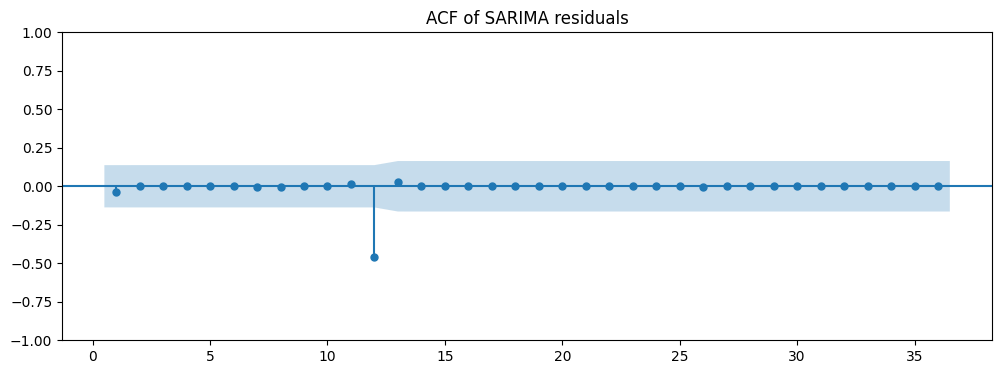

,lb_stat,lb_pvalue
6,0.2968,0.9995
12,46.7010,0.0000
18,46.8580,0.0002
24,46.8591,0.0035


In [34]:
sarima_resid = pd.Series(sarima.resid, index=train.index).dropna()

show(line_plot({"SARIMA residual": sarima_resid}, "SARIMA residuals", "Residual"))

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(sarima_resid, lags=36, ax=ax, zero=False)
ax.set_title("ACF of SARIMA residuals")
plt.show()

ljung_box = acorr_ljungbox(
    sarima_resid,
    lags=[6, 12, 18, 24],
    return_df=True,
)

display(ljung_box.round(4))

### Ljung-Box intuition

The Ljung-Box test jointly examines whether residual autocorrelations up to a chosen lag are zero.

- $H_0$: residuals are not autocorrelated up to that lag;
- small p-value: evidence that serial dependence remains.

Do not interpret this mechanically. With long series even small deviations can become statistically significant, while forecasting performance may still be strong. Diagnostics and out-of-sample performance should be considered together.

## 16. Small SARIMA model-selection experiment

Rather than using a giant grid search, we compare a compact set of plausible orders. This is pedagogically useful because exhaustive search over time-series models can be expensive and can encourage overfitting to one dataset.

We compare candidate models using AIC. Lower AIC is preferred **among models fitted to the same response data**.

In [17]:
CANDIDATE_SARIMA = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 0, 12)),
]
rows = []
for order, seasonal_order in CANDIDATE_SARIMA:
    try:
        fitted = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=100)

        rows.append({
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "AIC": fitted.aic,
            "BIC": fitted.bic,
        })
    except Exception as exc:
        rows.append({
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "AIC": np.nan,
            "BIC": np.nan,
            "error": str(exc),
        })

sarima_selection = pd.DataFrame(rows).sort_values("AIC", na_position="last")
display(sarima_selection.round(3))

,order,seasonal_order,AIC,BIC
0,"(0, 1, 1)","(0, 1, 1, 12)",88.941,98.470
2,"(1, 1, 1)","(0, 1, 1, 12)",90.648,103.352
3,"(1, 1, 1)","(1, 1, 0, 12)",140.720,153.447
1,"(1, 1, 0)","(1, 1, 0, 12)",145.547,155.093


## 17. State-space modelling: local level, trend and seasonality

A state-space model distinguishes between an unobserved latent state and noisy observations.

Generic transition equation:

$$
\mathbf{x}_t = F\mathbf{x}_{t-1} + \mathbf{w}_t.
$$

Observation equation:

$$
y_t = H\mathbf{x}_t + v_t.
$$

The Kalman filter recursively combines:

1. a model-based prediction of the latent state;
2. the new observation;
3. uncertainty in both sources.

Conceptually,

$$
\text{updated state}
=
\text{predicted state}
+
K_t\times\text{innovation}.
$$

We fit an unobserved-components model with local linear trend and a 12-month seasonal component.

In [49]:
ucm = UnobservedComponents(
    train,
    level="local linear trend",
    seasonal=SEASONAL_PERIOD,
).fit(disp=False)

ucm_pred = ucm.get_forecast(steps=len(test))
ucm_forecast = pd.Series(
    ucm_pred.predicted_mean.values,
    index=test.index,
    name="State-space UCM",
)

ucm_ci = ucm_pred.conf_int(alpha=0.05)
ucm_lower = pd.Series(ucm_ci.iloc[:, 0].values, index=test.index)
ucm_upper = pd.Series(ucm_ci.iloc[:, 1].values, index=test.index)

p = line_plot(
    {"Observed test": test, "State-space forecast": ucm_forecast},
    "State-space / Kalman-filter forecast",
    "CO₂ (ppm)",
)
p.varea(
    x=test.index,
    y1=ucm_lower.values,
    y2=ucm_upper.values,
    fill_alpha=0.18,
    legend_label="95% prediction interval",
)
show(p)

### Filtering vs smoothing vs forecasting

These three terms are easy to confuse:

- **Filtering:** estimate state $x_t$ using observations only up to $t$;
- **Smoothing:** estimate past state $x_t$ using observations that occur after $t$ as well;
- **Forecasting:** estimate future state or observation beyond the current endpoint.

The same state-space machinery can therefore support online tracking, retrospective reconstruction and future prediction.

## 18. Spectral analysis: looking at time series in the frequency domain

So far we have worked mainly in the **time domain**: lags 1, 2, 12, and so on.

Frequency-domain analysis asks a different question:

> At what periodicities does the series contain substantial variation?

A strong annual seasonal component in monthly data should appear near frequency

$$
f = \frac{1}{12}
$$

cycles per month.

Equivalently, the corresponding period is

$$
\text{period} = \frac{1}{f} \approx 12 \text{ months}.
$$

We first detrend the series using STL, because a huge low-frequency trend can otherwise dominate the periodogram.

In [36]:
detrended = (monthly - stl_trend).dropna()
frequencies, power = periodogram(detrended.values)

spectral = pd.DataFrame({"frequency": frequencies, "power": power})
spectral = spectral[spectral["frequency"] > 0].copy()
spectral["period_months"] = 1.0 / spectral["frequency"]

# Focus on interpretable periods between 2 and 120 months.
view = spectral[
    spectral["period_months"].between(2, 120)
].sort_values("period_months")

p = figure(
    width=950,
    height=380,
    title="Periodogram of detrended monthly CO₂",
    toolbar_location="above",
)
p.line(view["period_months"], view["power"], line_width=2)
p.xaxis.axis_label = "Period (months)"
p.yaxis.axis_label = "Spectral power"
p.add_tools(HoverTool(tooltips=[("period", "$x{0.00} months"), ("power", "$y{0.000}")]))
show(p)

display(
    spectral[
        spectral["period_months"].between(2, 120)
    ]
    .nlargest(10, "power")[["period_months", "frequency", "power"]]
    .round(4)
)

,period_months,frequency,power
44,11.9545,0.0837,1861.4594
88,5.9773,0.1673,100.2035
43,12.2326,0.0817,66.0418
45,11.6889,0.0856,29.1999
87,6.0460,0.1654,23.0820
42,12.5238,0.0798,11.2270
46,11.4348,0.0875,8.4481
41,12.8293,0.0779,7.2647
86,6.1163,0.1635,6.9250
89,5.9101,0.1692,4.5610


### What does a spectral peak mean?

If the strongest peak occurs close to 12 months, that independently confirms the annual seasonal structure we already saw in:

- the raw plot;
- STL decomposition;
- lag-based analysis.

That is an important modelling habit: **use several complementary views of the same process rather than trusting one diagnostic**.

## 19. Machine-learning forecasting with lag features

A supervised-learning model does not inherently understand time. We must explicitly construct features representing historical state.

For month $t$, we can use features such as:

- $y_{t-1}$, $y_{t-2}$, $y_{t-3}$;
- $y_{t-6}$;
- $y_{t-12}$ and $y_{t-24}$;
- rolling means;
- deterministic calendar encodings.

We use `HistGradientBoostingRegressor`. Importantly, future observations are **not** used to construct recursive forecasts: once the test horizon begins, each new prediction is appended to history and becomes an input to the next step.

In [50]:
ML_LAGS = [1, 2, 3, 6, 12, 13, 24]


def make_ml_feature(history: Sequence[float], timestamp: pd.Timestamp) -> pd.DataFrame:
    h = np.asarray(history, dtype=float)
    if len(h) < max(ML_LAGS):
        raise ValueError("Insufficient history for requested lag features.")

    month_angle = 2.0 * np.pi * timestamp.month / 12.0

    row = {
        **{f"lag_{lag}": h[-lag] for lag in ML_LAGS},
        "rolling_mean_3": h[-3:].mean(),
        "rolling_mean_6": h[-6:].mean(),
        "rolling_mean_12": h[-12:].mean(),
        "month_sin": np.sin(month_angle),
        "month_cos": np.cos(month_angle),
        "time_index": len(h),
    }
    return pd.DataFrame([row])


def make_ml_training_frame(series: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
    rows = []
    targets = []

    values = series.values.astype(float)
    for i in range(max(ML_LAGS), len(series)):
        ts = series.index[i]
        feature = make_ml_feature(values[:i], ts)
        rows.append(feature.iloc[0].to_dict())
        targets.append(values[i])

    X = pd.DataFrame(rows, index=series.index[max(ML_LAGS):])
    y = pd.Series(targets, index=X.index, name="target")
    return X, y


X_train_ml, y_train_ml = make_ml_training_frame(train)

ml_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
).fit(X_train_ml, y_train_ml)

history = list(train.values.astype(float))
ml_predictions = []

for ts in test.index:
    X_next = make_ml_feature(history, ts)
    pred = float(ml_model.predict(X_next)[0])
    ml_predictions.append(pred)
    history.append(pred)

ml_forecast = pd.Series(ml_predictions, index=test.index, name="ML recursive")

show(line_plot(
    {"Observed test": test, "ML recursive": ml_forecast},
    "Recursive gradient-boosting forecast",
    "CO₂ (ppm)",
))

### Why recursive forecasting can drift

During training, lagged features are built from true historical observations. During multi-step forecasting, later features contain **previous model predictions**.

Therefore forecast error can propagate:

```text
prediction error at t+1
        ↓
becomes input lag for t+2
        ↓
changes prediction at t+2
        ↓
propagates further
```

This is one reason a powerful supervised learner is not automatically superior to a well-specified statistical forecasting model.

## 20. Compare all models on the same unseen future

A fair comparison requires:

- identical training endpoint;
- identical forecast horizon;
- identical target values;
- identical metrics.

We compare five different philosophies:

1. naïve;
2. seasonal naïve;
3. exponential smoothing;
4. SARIMA;
5. state-space structural model;
6. machine-learning recursive forecast.

In [38]:
metrics = ForecastMetrics(seasonal_period=SEASONAL_PERIOD)

rows = [
    metrics.evaluate("Naive", train.values, test.values, naive_forecast.values),
    metrics.evaluate("Seasonal Naive", train.values, test.values, seasonal_naive.values),
    metrics.evaluate("ETS / Holt-Winters", train.values, test.values, ets_forecast.values),
    metrics.evaluate("SARIMA", train.values, test.values, sarima_forecast.values),
    metrics.evaluate("State Space UCM", train.values, test.values, ucm_forecast.values),
    metrics.evaluate("HistGradientBoosting", train.values, test.values, ml_forecast.values),
]

benchmark_df = table_metrics(rows)
display(benchmark_df)

show(line_plot(
    {
        "Observed": test,
        "Seasonal naive": seasonal_naive,
        "ETS": ets_forecast,
        "SARIMA": sarima_forecast,
        "State space": ucm_forecast,
        "ML": ml_forecast,
    },
    "Forecast comparison on held-out future",
    "CO₂ (ppm)",
))

,model,MAE,RMSE,sMAPE_pct,MASE
0,SARIMA,0.8141,0.8881,0.2199,0.5099
1,State Space UCM,0.8185,0.8925,0.2211,0.5127
2,ETS / Holt-Winters,1.3931,1.5094,0.3759,0.8726
3,Naive,2.8393,3.3364,0.7699,1.7784
4,Seasonal Naive,2.8657,3.1088,0.7779,1.7949
5,HistGradientBoosting,3.0949,3.4745,0.8397,1.9385


## 21. How to read the benchmark table

Do not ask only, “Which model has the smallest RMSE?” Ask *why*.

### If seasonal naïve performs surprisingly well

The seasonal signal is strong enough that last year's corresponding month already contains substantial predictive information.

### If ETS performs strongly

Smooth level/trend/seasonal evolution is capturing most of the predictable structure.

### If SARIMA performs strongly

Lagged stochastic dependence and differencing are adding useful information beyond deterministic seasonal smoothing.

### If the state-space model performs strongly

A latent level/trend representation updated recursively through the Kalman filter matches the underlying dynamics well.

### If ML performs strongly

Non-linear interactions among lag, rolling and calendar features may matter.

### If ML performs poorly

That is not a failure of machine learning. It may simply mean:

- the series is small;
- the dynamics are smooth and low-dimensional;
- recursive errors accumulate;
- classical structural assumptions are already well matched to the process.

This is model selection by **problem structure**, not by fashion.

## 22. Rolling-origin validation

A single holdout period is useful, but model ranking can depend on where the test period begins.

Rolling-origin validation repeatedly asks:

> If I had stopped at this historical date, how well would the model have forecast the next few months?

Conceptually:

```text
Fold 1: TRAIN █████████████ | TEST ███
Fold 2: TRAIN █████████████████ | TEST ███
Fold 3: TRAIN █████████████████████ | TEST ███
```

This respects chronology and is the time-series analogue of cross-validation.

Below we demonstrate it with the seasonal-naïve and ETS models because they refit quickly.

In [43]:
def rolling_origin_backtest(
    series: pd.Series,
    initial_train_size: int,
    horizon: int,
    step: int,
) -> pd.DataFrame:
    metric = ForecastMetrics(seasonal_period=SEASONAL_PERIOD)
    rows = []

    origin = initial_train_size
    fold = 1

    while origin + horizon <= len(series):
        tr = series.iloc[:origin]
        te = series.iloc[origin: origin + horizon]

        snaive = seasonal_naive_forecast(tr, horizon, SEASONAL_PERIOD)
        snaive.index = te.index

        ets = ExponentialSmoothing(
            tr,
            trend="add",
            damped_trend=True,
            seasonal="add",
            seasonal_periods=SEASONAL_PERIOD,
            initialization_method="estimated",
        ).fit(optimized=True)
        ets_fc = pd.Series(ets.forecast(horizon).values, index=te.index)

        for name, pred in {
            "Seasonal Naive": snaive,
            "ETS": ets_fc,
        }.items():
            result = metric.evaluate(name, tr.values, te.values, pred.values)
            result.update({
                "fold": fold,
                "train_end": tr.index[-1],
                "test_start": te.index[0],
                "test_end": te.index[-1],
            })
            rows.append(result)

        fold += 1
        origin += step

    return pd.DataFrame(rows)


backtest_df = rolling_origin_backtest(
    monthly,
    initial_train_size=300,
    horizon=12,
    step=24,
)

display(backtest_df.round(4))

display(
    backtest_df.groupby("model")[["MAE", "RMSE", "sMAPE_pct", "MASE"]]
    .agg(["mean", "std"])
    .round(4)
)

,model,MAE,RMSE,sMAPE_pct,MASE,fold,train_end,test_start,test_end
0,Seasonal Naive,1.8875,1.9604,0.5520,1.7423,1,1983-02-01,1983-03-01,1984-02-01
1,ETS,0.7456,0.8130,0.2174,0.6883,1,1983-02-01,1983-03-01,1984-02-01
2,Seasonal Naive,1.3933,1.4410,0.4036,1.2313,2,1985-02-01,1985-03-01,1986-02-01
3,ETS,0.2785,0.3481,0.0804,0.2462,2,1985-02-01,1985-03-01,1986-02-01
4,Seasonal Naive,2.0292,2.0908,0.5826,1.7670,3,1987-02-01,1987-03-01,1988-02-01
5,ETS,0.7811,0.9554,0.2238,0.6802,3,1987-02-01,1987-03-01,1988-02-01
6,Seasonal Naive,1.3346,1.3596,0.3785,1.0955,4,1989-02-01,1989-03-01,1990-02-01
7,ETS,0.3050,0.3591,0.0866,0.2504,4,1989-02-01,1989-03-01,1990-02-01
8,Seasonal Naive,1.4287,1.5186,0.4018,1.1691,5,1991-02-01,1991-03-01,1992-02-01
9,ETS,0.5007,0.5856,0.1406,0.4097,5,1991-02-01,1991-03-01,1992-02-01


MAE            RMSE         sMAPE_pct            MASE  \
                  mean     std    mean     std      mean     std    mean   
model                                                                      
ETS             0.5126  0.1837  0.5972  0.2051    0.1444  0.0528  0.4305   
Seasonal Naive  1.5049  0.3980  1.5815  0.3717    0.4254  0.1166  1.2670   

                        
                   std  
model                   
ETS             0.1663  
Seasonal Naive  0.3746

## 23. The modelling workflow as a reusable decision process

A disciplined time-series project can be organised as:

### Stage A — Understand the temporal contract

- What does one observation represent?
- Is spacing regular?
- What is the natural seasonal period?
- Are missing dates meaningful?

### Stage B — Explore

- plot the series;
- inspect rolling behaviour;
- identify trend, seasonality and breaks;
- decompose.

### Stage C — Characterise dependence

- inspect ACF and PACF;
- test stationarity;
- difference when theoretically justified;
- inspect periodicity in the frequency domain when useful.

### Stage D — Establish baselines

Never skip naïve and seasonal-naïve forecasts.

### Stage E — Fit models from different families

- ETS for evolving level/trend/seasonality;
- ARIMA/SARIMA for stochastic lag structure;
- state-space models for latent components and recursive filtering;
- ML when nonlinear feature interactions and richer covariates justify it.

### Stage F — Diagnose

A good model should leave residuals that are close to white noise.

### Stage G — Validate temporally

Never shuffle observations merely because ordinary ML tooling does so by default.

### Stage H — Quantify uncertainty

Forecasts are distributions, not just point estimates.

## 24. Important theoretical connections

### 24.1 Random walk and differencing

If

$$
y_t = y_{t-1} + \varepsilon_t,
$$

then

$$
\Delta y_t = \varepsilon_t.
$$

A non-stationary random walk becomes stationary after first differencing.

### 24.2 AR(1) persistence

For

$$
y_t = \phi y_{t-1} + \varepsilon_t,
$$

with $|\phi|<1$, the effect of a shock decays geometrically:

$$
\phi,\phi^2,\phi^3,\ldots
$$

When $\phi$ is close to one, shocks decay slowly and the process is highly persistent.

### 24.3 Backshift notation

Define

$$
By_t = y_{t-1}.
$$

Then AR(1) can be written compactly as

$$
(1-\phi B)y_t = \varepsilon_t.
$$

ARIMA uses this same notation:

$$
\phi(B)(1-B)^d y_t = \theta(B)\varepsilon_t.
$$

### 24.4 Forecast uncertainty increases with horizon

A one-step forecast has less accumulated uncertainty than a 24-step forecast. This is why prediction intervals usually widen as the horizon grows.

## 25. Common mistakes this case study is designed to prevent

### Mistake 1 — Random train/test splitting

It leaks future temporal structure into the past.

### Mistake 2 — Treating ACF/PACF as automatic model selectors

They are diagnostic summaries, not an infallible algorithm.

### Mistake 3 — Differencing until every plot “looks flat”

Over-differencing can introduce unnecessary moving-average structure and increase forecast variance.

### Mistake 4 — Choosing a model only by training fit

AIC helps, but the final question is still future forecasting performance.

### Mistake 5 — Ignoring residual autocorrelation

A low training RMSE does not prove that the model extracted all predictable temporal structure.

### Mistake 6 — Assuming complex ML must win

Small, smooth, strongly seasonal datasets often favour parsimonious statistical models.

### Mistake 7 — Reporting only point forecasts

Operational decisions often depend on uncertainty bands, not merely expected values.

## 26. Suggested exercises

Try these in increasing order of difficulty.

### Exercise 1 — Compare additive vs multiplicative ETS

Fit both seasonal forms. Which has lower holdout error? Does the visual structure support that choice?

### Exercise 2 — Search SARIMA orders more systematically

Explore small values of $p,q,P,Q \in \{0,1,2\}$ while keeping differencing choices grounded in diagnostics. Compare AIC and future RMSE.

### Exercise 3 — Change the forecast horizon

Compare 6-, 12-, 24- and 36-month horizons. Does the model ranking change?

### Exercise 4 — Inspect seasonal residual structure

After fitting each model, compute ACF at lags 12, 24 and 36. Which model removes annual dependence most effectively?

### Exercise 5 — Add uncertainty evaluation

Check the empirical coverage of 80% and 95% prediction intervals.

### Exercise 6 — Improve the ML forecaster

Experiment with:

- more lag features;
- rolling standard deviations;
- exponentially weighted averages;
- direct multi-horizon models;
- `RandomForestRegressor`;
- XGBoost/LightGBM if installed.

### Exercise 7 — Structural break analysis

Fit separate trends to earlier and later historical windows. Does the long-run growth rate appear constant?

### Exercise 8 — Compare monthly and weekly modelling

Repeat the analysis at weekly frequency. What changes when the seasonal period becomes approximately 52 instead of 12?

## 27. Final conceptual summary

The most important lesson is not a particular algorithm.

A time-series analyst repeatedly moves through this loop:

```text
Observe temporal structure
        ↓
Form statistical assumptions
        ↓
Transform / model dependence
        ↓
Forecast the unseen future
        ↓
Inspect residuals and uncertainty
        ↓
Backtest across historical origins
        ↓
Revise the model
```

The core progression demonstrated here is:

$$
	ext{trend/seasonality}
ightarrow
	ext{stationarity}
ightarrow
	ext{ACF/PACF}
ightarrow
	ext{ARIMA/SARIMA}
ightarrow
	ext{diagnostics}
ightarrow
	ext{state space}
ightarrow
	ext{time-aware validation}.
$$

That progression is foundational even when the final production model is a gradient-boosted tree or a neural forecaster, because **the data-generating process still has temporal dependence, forecasting horizons, leakage risks and uncertainty**.